# Shared-charge MS_DSA vs lysine B-factors

Same layout as `eval4.ipynb`, with B-factors instead of asa_nz. B-factors come from the PDB structures and are
**z-scores**, normalized over all protein heavy atoms of the same chain (0 = the chain average, positive = more mobile
than the rest of the chain). All contact classes use the same PDB B-factor column.

- **NZ max**: `nz_bfactor_z_max_max` - max over the chains containing the lysine, then over the peptide's lysines
- **NZ min**: `nz_bfactor_z_min_min` - min over chains, then over lysines
- **Residue max / min**: `avg_bfactor_z_mean_max` / `avg_bfactor_z_mean_min` - residue-average B-factor (mean over
  structures) of each lysine, then max / min over the peptide's lysines

MS_DSA is `MS_DSA_shared_charges` in two versions: **A** zero areas included, **B** zero areas excluded.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dsa.ms_dsa.evaluation1.ms_dsa_annotator import MSDSAAnnotator
from dsa.ms_dsa.evaluation1.plots import (plot_dsa_vs_sasa_with_binding_annotation, binned_histogram, plot_runs,
                                          correlation_table)

plt.rcParams.update({"font.size": 8, "figure.dpi": 100})

RUN_INDICES = range(5)
ms_dsa_by_run = {run_index: MSDSAAnnotator.load_run(run_index) for run_index in RUN_INDICES}

In [2]:
# plot settings
dsa_column = "MS_DSA_shared_charges"
bond_type = "salt_bridge"       # None for any contact
strict = False                  # inter-chain lysines that have no intra-chain PDB contact

bfactor_columns = {
    "NZ max": "nz_bfactor_z_max_max",
    "NZ min": "nz_bfactor_z_min_min",
    "residue max": "avg_bfactor_z_mean_max",
    "residue min": "avg_bfactor_z_mean_min",
}

# histogram bin edges (z-scores): width 1 from -3 to 5, open-ended below -3 and above 5
bfactor_bins = [-np.inf, *np.arange(-3.0, 5.5, 1.0), np.inf]

versions = {
    "A. zero areas included": ["channel_absent", "no_shared_charges"],
    "B. zero areas excluded": ["channel_absent", "no_shared_charges", "zero_area_shared"],
}
print("B-factor bins:", bfactor_bins)

B-factor bins: [-inf, np.float64(-3.0), np.float64(-2.0), np.float64(-1.0), np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), inf]


In [3]:
# where the B-factor z-scores lie (all runs, peptides with a shared-charge MS_DSA)
all_runs = pd.concat(ms_dsa_by_run.values())
all_runs = all_runs[all_runs[dsa_column].notna()]
all_runs[list(bfactor_columns.values())].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(2)

,nz_bfactor_z_max_max,nz_bfactor_z_min_min,avg_bfactor_z_mean_max,avg_bfactor_z_mean_min
count,3970.00,3970.00,4080.00,4080.00
mean,1.99,-0.52,0.30,0.21
std,1.55,1.25,0.85,0.82
min,-3.32,-10.22,-3.32,-3.32
1%,-1.19,-3.60,-1.39,-1.53
5%,-0.19,-2.18,-0.86,-0.91
25%,0.93,-1.22,-0.27,-0.34
50%,1.85,-0.61,0.23,0.13
75%,2.89,0.19,0.82,0.66
95%,4.87,1.47,1.71,1.54


## A. Zero areas included

For each B-factor column: the Spearman correlation with `MS_DSA_shared_charges` per run and contact class,
the scatter plot and the binned histogram.

NZ max (nz_bfactor_z_max_max): Spearman correlation with MS_DSA_shared_charges


spearman                           n                     
group    Inter Intra AF Not Contact  Inter Intra AF Not Contact
run                                                            
0        0.199    0.054       0.070  153.0    290.0       311.0
1        0.070    0.006      -0.001  130.0    235.0       279.0
2        0.113    0.010       0.043  155.0    245.0       250.0
3        0.053   -0.022       0.018  147.0    252.0       267.0
4        0.019   -0.003       0.044  186.0    322.0       343.0

Inter PDB: 166 rows  (0.144 with MS_DSA_shared_charges < 0.9)
Intra PDB: 455 rows  (0.178 with MS_DSA_shared_charges < 0.9)
Intra AF: 507 rows  (0.199 with MS_DSA_shared_charges < 0.9)
Not contact: 939 rows  (0.224 with MS_DSA_shared_charges < 0.9)
Inter PDB: 139 rows  (0.185 with MS_DSA_shared_charges < 0.9)
Intra PDB: 388 rows  (0.212 with MS_DSA_shared_charges < 0.9)
Intra AF: 426 rows  (0.240 with MS_DSA_shared_charges < 0.9)
Not contact: 876 rows  (0.220 with MS_DSA_shared_charges < 0.9)
Inter PDB: 165 rows  (0.142 with MS_DSA_shared_charges < 0.9)
Intra PDB: 418 rows  (0.196 with MS_DSA_shared_charges < 0.9)
Intra AF: 411 rows  (0.223 with MS_DSA_shared_charges < 0.9)
Not contact: 771 rows  (0.225 with MS_DSA_shared_charges < 0.9)
Inter PDB: 155 rows  (0.224 with MS_DSA_shared_charges < 0.9)
Intra PDB: 424 rows  (0.206 with MS_DSA_shared_charges < 0.9)
Intra AF: 460 rows  (0.215 with MS_DSA_shared_charges < 0.9)
Not contact: 825 rows  (0.255 with MS_DSA_shared_charges < 0.9)
Inte

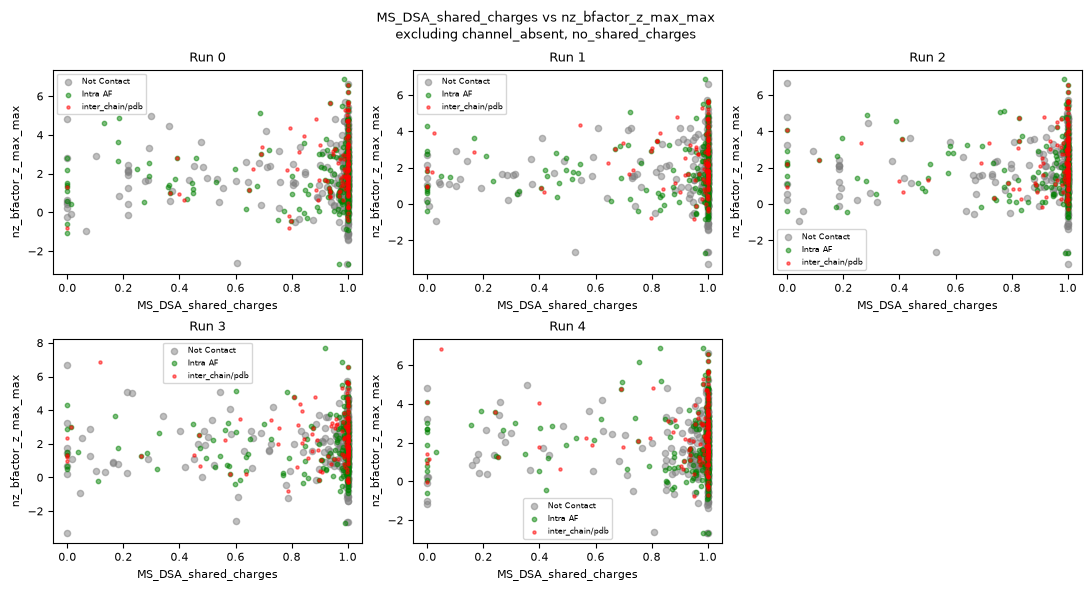

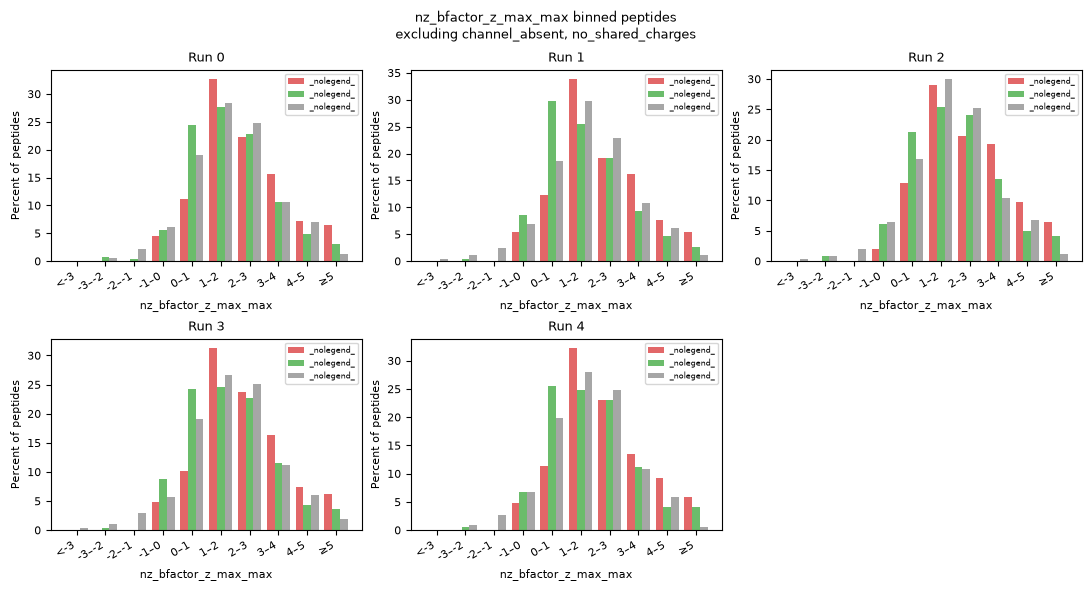

NZ min (nz_bfactor_z_min_min): Spearman correlation with MS_DSA_shared_charges


spearman                           n                     
group    Inter Intra AF Not Contact  Inter Intra AF Not Contact
run                                                            
0       -0.005    0.041       0.050  153.0    290.0       311.0
1       -0.088   -0.045       0.070  130.0    235.0       279.0
2        0.073    0.131       0.103  155.0    245.0       250.0
3       -0.041   -0.035      -0.009  147.0    252.0       267.0
4       -0.076    0.030       0.053  186.0    322.0       343.0

Inter PDB: 166 rows  (0.144 with MS_DSA_shared_charges < 0.9)
Intra PDB: 455 rows  (0.178 with MS_DSA_shared_charges < 0.9)
Intra AF: 507 rows  (0.199 with MS_DSA_shared_charges < 0.9)
Not contact: 939 rows  (0.224 with MS_DSA_shared_charges < 0.9)
Inter PDB: 139 rows  (0.185 with MS_DSA_shared_charges < 0.9)
Intra PDB: 388 rows  (0.212 with MS_DSA_shared_charges < 0.9)
Intra AF: 426 rows  (0.240 with MS_DSA_shared_charges < 0.9)
Not contact: 876 rows  (0.220 with MS_DSA_shared_charges < 0.9)
Inter PDB: 165 rows  (0.142 with MS_DSA_shared_charges < 0.9)
Intra PDB: 418 rows  (0.196 with MS_DSA_shared_charges < 0.9)
Intra AF: 411 rows  (0.223 with MS_DSA_shared_charges < 0.9)
Not contact: 771 rows  (0.225 with MS_DSA_shared_charges < 0.9)


Inter PDB: 155 rows  (0.224 with MS_DSA_shared_charges < 0.9)
Intra PDB: 424 rows  (0.206 with MS_DSA_shared_charges < 0.9)
Intra AF: 460 rows  (0.215 with MS_DSA_shared_charges < 0.9)
Not contact: 825 rows  (0.255 with MS_DSA_shared_charges < 0.9)
Inter PDB: 199 rows  (0.113 with MS_DSA_shared_charges < 0.9)
Intra PDB: 535 rows  (0.169 with MS_DSA_shared_charges < 0.9)
Intra AF: 570 rows  (0.184 with MS_DSA_shared_charges < 0.9)
Not contact: 1070 rows  (0.195 with MS_DSA_shared_charges < 0.9)


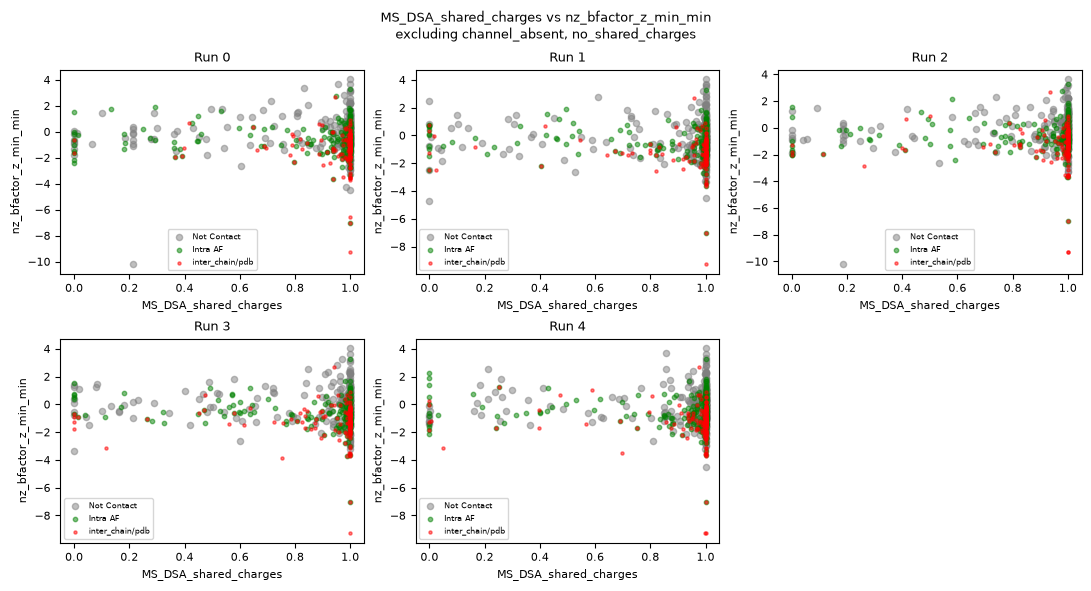

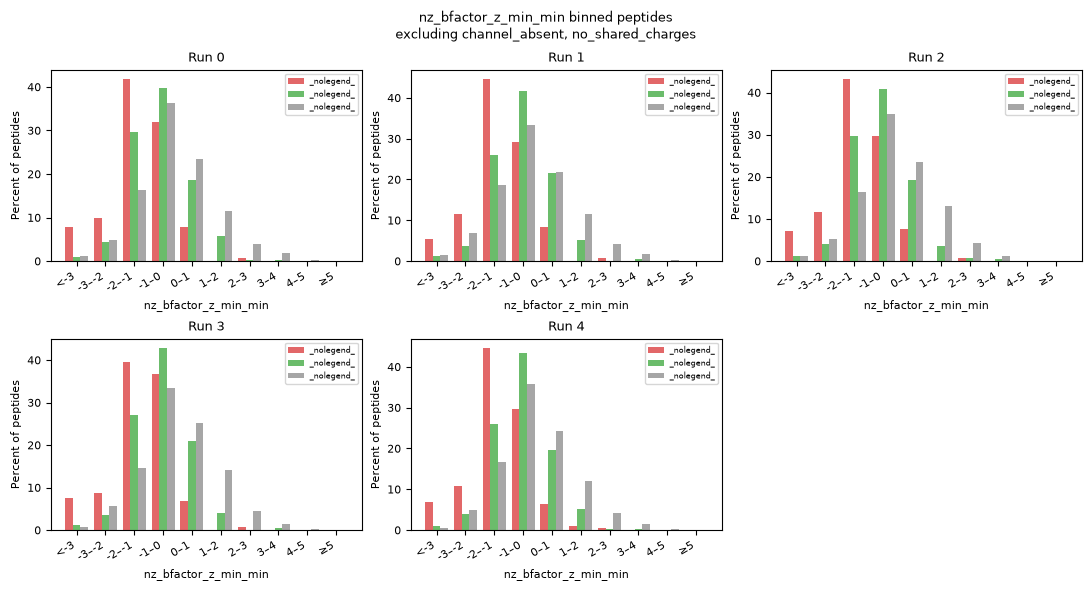

residue max (avg_bfactor_z_mean_max): Spearman correlation with MS_DSA_shared_charges


spearman                           n                     
group    Inter Intra AF Not Contact  Inter Intra AF Not Contact
run                                                            
0        0.119    0.065       0.019  153.0    295.0       326.0
1       -0.057   -0.012       0.030  130.0    239.0       294.0
2        0.117    0.081       0.004  155.0    249.0       264.0
3       -0.018   -0.001      -0.094  147.0    260.0       282.0
4        0.018    0.039       0.025  186.0    331.0       359.0

Inter PDB: 166 rows  (0.144 with MS_DSA_shared_charges < 0.9)
Intra PDB: 455 rows  (0.178 with MS_DSA_shared_charges < 0.9)
Intra AF: 507 rows  (0.199 with MS_DSA_shared_charges < 0.9)
Not contact: 939 rows  (0.224 with MS_DSA_shared_charges < 0.9)
Inter PDB: 139 rows  (0.185 with MS_DSA_shared_charges < 0.9)
Intra PDB: 388 rows  (0.212 with MS_DSA_shared_charges < 0.9)
Intra AF: 426 rows  (0.240 with MS_DSA_shared_charges < 0.9)
Not contact: 876 rows  (0.220 with MS_DSA_shared_charges < 0.9)
Inter PDB: 165 rows  (0.142 with MS_DSA_shared_charges < 0.9)
Intra PDB: 418 rows  (0.196 with MS_DSA_shared_charges < 0.9)
Intra AF: 411 rows  (0.223 with MS_DSA_shared_charges < 0.9)
Not contact: 771 rows  (0.225 with MS_DSA_shared_charges < 0.9)


Inter PDB: 155 rows  (0.224 with MS_DSA_shared_charges < 0.9)
Intra PDB: 424 rows  (0.206 with MS_DSA_shared_charges < 0.9)
Intra AF: 460 rows  (0.215 with MS_DSA_shared_charges < 0.9)
Not contact: 825 rows  (0.255 with MS_DSA_shared_charges < 0.9)
Inter PDB: 199 rows  (0.113 with MS_DSA_shared_charges < 0.9)
Intra PDB: 535 rows  (0.169 with MS_DSA_shared_charges < 0.9)
Intra AF: 570 rows  (0.184 with MS_DSA_shared_charges < 0.9)
Not contact: 1070 rows  (0.195 with MS_DSA_shared_charges < 0.9)


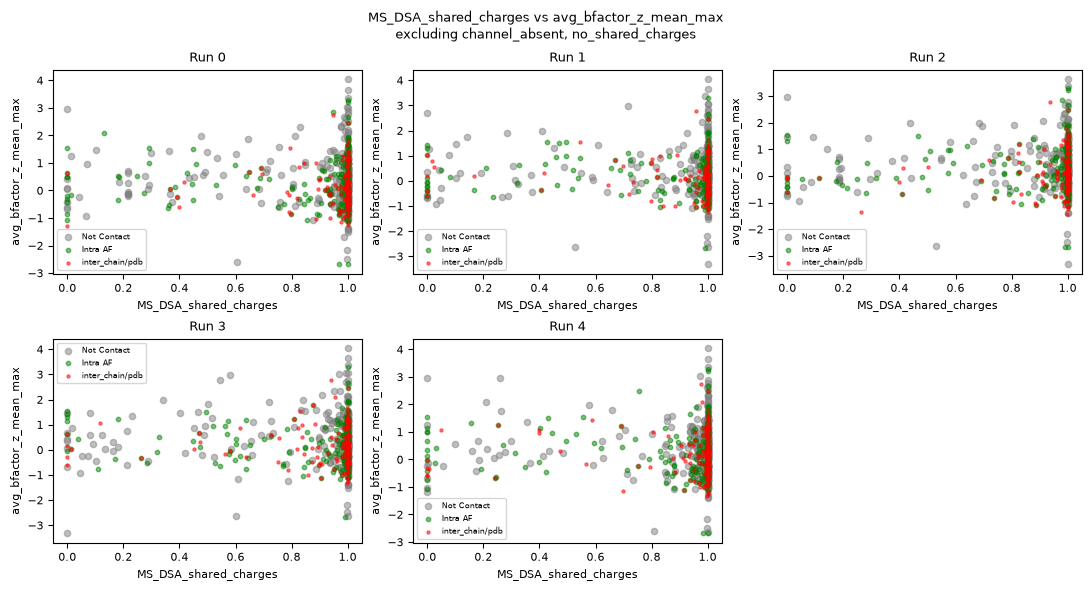

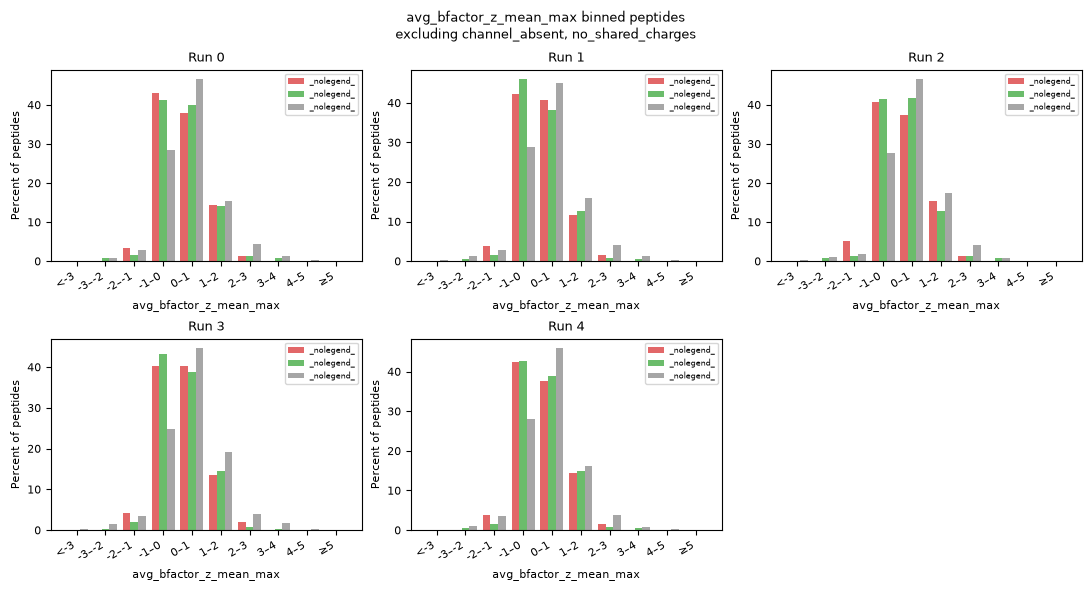

residue min (avg_bfactor_z_mean_min): Spearman correlation with MS_DSA_shared_charges


spearman                           n                     
group    Inter Intra AF Not Contact  Inter Intra AF Not Contact
run                                                            
0        0.063    0.054      -0.000  153.0    295.0       326.0
1       -0.065   -0.039       0.010  130.0    239.0       294.0
2        0.036    0.056      -0.023  155.0    249.0       264.0
3       -0.094   -0.054      -0.111  147.0    260.0       282.0
4       -0.024   -0.021      -0.011  186.0    331.0       359.0

Inter PDB: 166 rows  (0.144 with MS_DSA_shared_charges < 0.9)
Intra PDB: 455 rows  (0.178 with MS_DSA_shared_charges < 0.9)
Intra AF: 507 rows  (0.199 with MS_DSA_shared_charges < 0.9)
Not contact: 939 rows  (0.224 with MS_DSA_shared_charges < 0.9)


Inter PDB: 139 rows  (0.185 with MS_DSA_shared_charges < 0.9)
Intra PDB: 388 rows  (0.212 with MS_DSA_shared_charges < 0.9)
Intra AF: 426 rows  (0.240 with MS_DSA_shared_charges < 0.9)
Not contact: 876 rows  (0.220 with MS_DSA_shared_charges < 0.9)
Inter PDB: 165 rows  (0.142 with MS_DSA_shared_charges < 0.9)
Intra PDB: 418 rows  (0.196 with MS_DSA_shared_charges < 0.9)
Intra AF: 411 rows  (0.223 with MS_DSA_shared_charges < 0.9)
Not contact: 771 rows  (0.225 with MS_DSA_shared_charges < 0.9)
Inter PDB: 155 rows  (0.224 with MS_DSA_shared_charges < 0.9)
Intra PDB: 424 rows  (0.206 with MS_DSA_shared_charges < 0.9)
Intra AF: 460 rows  (0.215 with MS_DSA_shared_charges < 0.9)
Not contact: 825 rows  (0.255 with MS_DSA_shared_charges < 0.9)
Inter PDB: 199 rows  (0.113 with MS_DSA_shared_charges < 0.9)
Intra PDB: 535 rows  (0.169 with MS_DSA_shared_charges < 0.9)
Intra AF: 570 rows  (0.184 with MS_DSA_shared_charges < 0.9)
Not contact: 1070 rows  (0.195 with MS_DSA_shared_charges < 0.9)


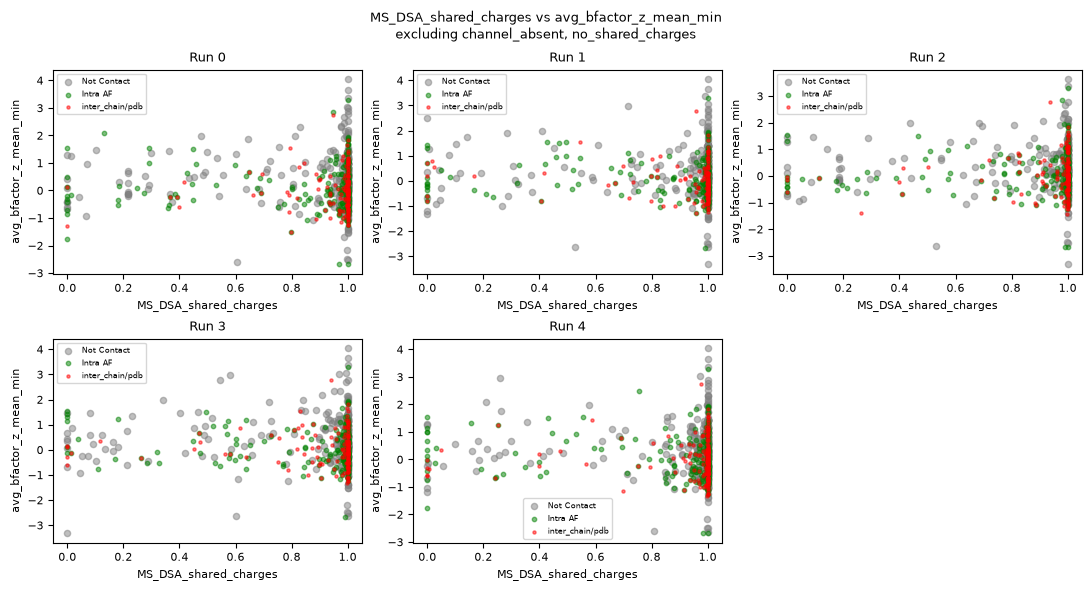

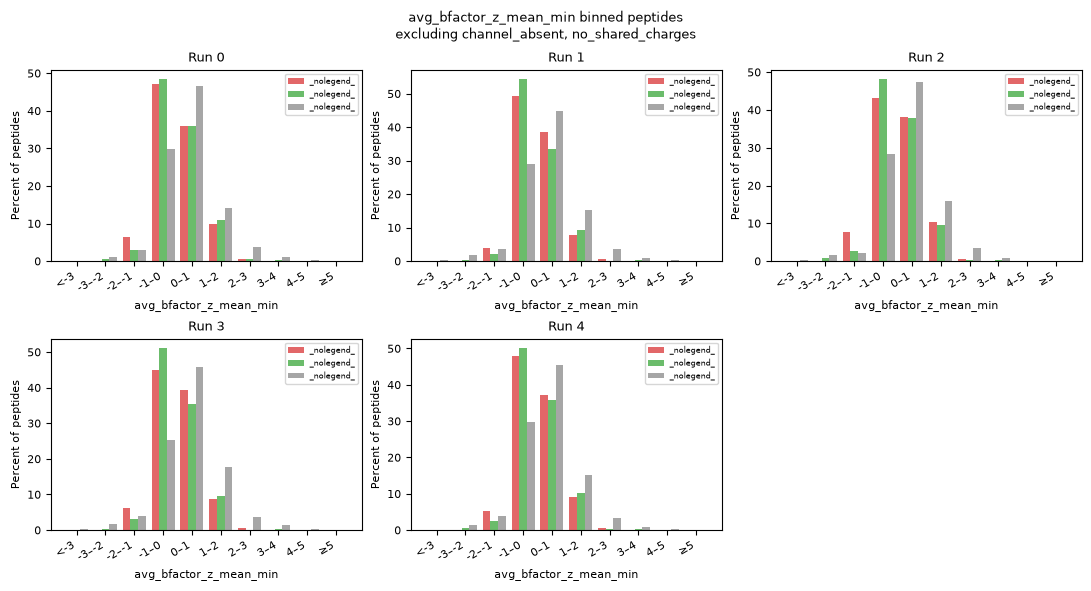

In [4]:
common = dict(bond_type=bond_type, strict=strict, exclude=versions["A. zero areas included"])
for name, column in bfactor_columns.items():
    print(f"{name} ({column}): Spearman correlation with {dsa_column}")
    display(correlation_table(ms_dsa_by_run, dsa_column, column, **common))
    plot_runs(ms_dsa_by_run, plot_dsa_vs_sasa_with_binding_annotation, sasa_column=column, dsa_column=dsa_column, **common)
    plt.show()
    plot_runs(ms_dsa_by_run, binned_histogram, column=column, bins=bfactor_bins, require=dsa_column, **common)
    plt.show()

## B. Zero areas excluded

For each B-factor column: the Spearman correlation with `MS_DSA_shared_charges` per run and contact class,
the scatter plot and the binned histogram.

NZ max (nz_bfactor_z_max_max): Spearman correlation with MS_DSA_shared_charges


spearman                          n                     
group    Inter Intra AF Not Contact Inter Intra AF Not Contact
run                                                           
0        0.180   -0.029       0.086  72.0    116.0       146.0
1       -0.134   -0.046       0.177  57.0     94.0       121.0
2        0.197    0.049       0.211  69.0    110.0       124.0
3        0.162    0.031       0.102  75.0    118.0       135.0
4        0.116   -0.067       0.099  78.0    118.0       146.0

Inter PDB: 72 rows  (0.278 with MS_DSA_shared_charges < 0.9)
Intra PDB: 185 rows  (0.351 with MS_DSA_shared_charges < 0.9)
Intra AF: 203 rows  (0.404 with MS_DSA_shared_charges < 0.9)
Not contact: 432 rows  (0.426 with MS_DSA_shared_charges < 0.9)
Inter PDB: 57 rows  (0.351 with MS_DSA_shared_charges < 0.9)
Intra PDB: 170 rows  (0.388 with MS_DSA_shared_charges < 0.9)
Intra AF: 179 rows  (0.447 with MS_DSA_shared_charges < 0.9)
Not contact: 380 rows  (0.445 with MS_DSA_shared_charges < 0.9)


Inter PDB: 69 rows  (0.275 with MS_DSA_shared_charges < 0.9)
Intra PDB: 189 rows  (0.365 with MS_DSA_shared_charges < 0.9)
Intra AF: 178 rows  (0.433 with MS_DSA_shared_charges < 0.9)
Not contact: 387 rows  (0.390 with MS_DSA_shared_charges < 0.9)
Inter PDB: 75 rows  (0.387 with MS_DSA_shared_charges < 0.9)
Intra PDB: 203 rows  (0.379 with MS_DSA_shared_charges < 0.9)
Intra AF: 202 rows  (0.411 with MS_DSA_shared_charges < 0.9)
Not contact: 406 rows  (0.441 with MS_DSA_shared_charges < 0.9)
Inter PDB: 78 rows  (0.218 with MS_DSA_shared_charges < 0.9)
Intra PDB: 216 rows  (0.356 with MS_DSA_shared_charges < 0.9)
Intra AF: 209 rows  (0.388 with MS_DSA_shared_charges < 0.9)
Not contact: 443 rows  (0.406 with MS_DSA_shared_charges < 0.9)


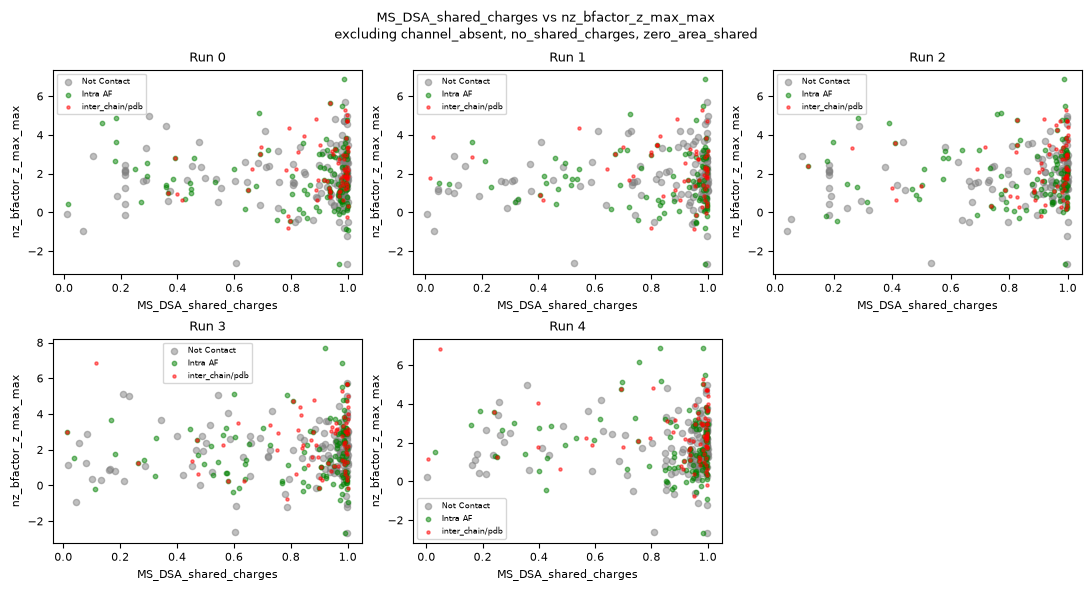

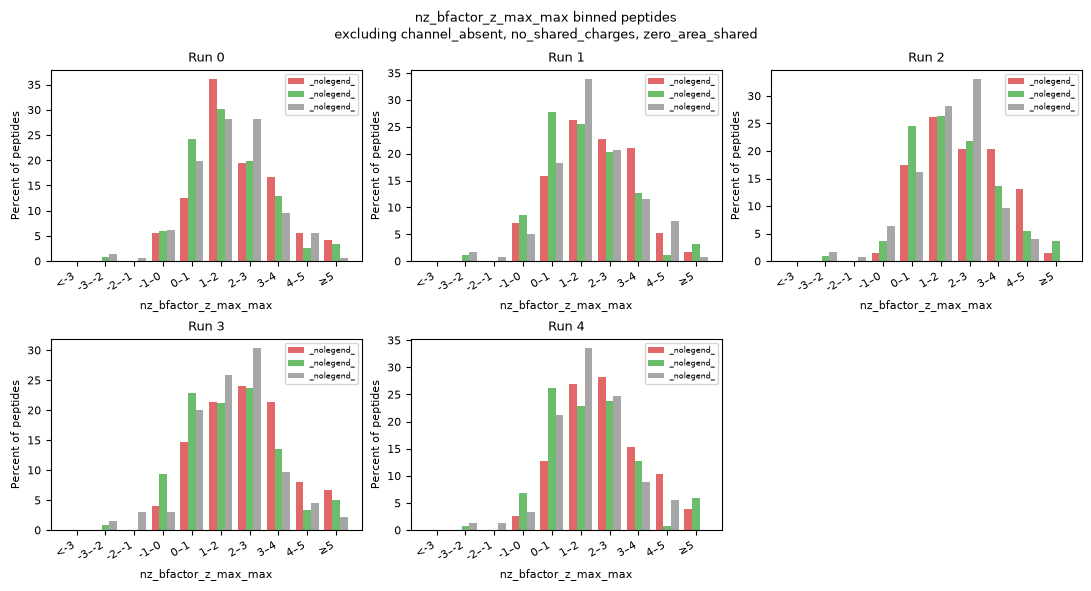

NZ min (nz_bfactor_z_min_min): Spearman correlation with MS_DSA_shared_charges


spearman                          n                     
group    Inter Intra AF Not Contact Inter Intra AF Not Contact
run                                                           
0       -0.167   -0.159      -0.119  72.0    116.0       146.0
1       -0.054   -0.245      -0.102  57.0     94.0       121.0
2       -0.180   -0.164       0.033  69.0    110.0       124.0
3       -0.219   -0.200      -0.097  75.0    118.0       135.0
4       -0.227   -0.117      -0.097  78.0    118.0       146.0

Inter PDB: 72 rows  (0.278 with MS_DSA_shared_charges < 0.9)
Intra PDB: 185 rows  (0.351 with MS_DSA_shared_charges < 0.9)
Intra AF: 203 rows  (0.404 with MS_DSA_shared_charges < 0.9)
Not contact: 432 rows  (0.426 with MS_DSA_shared_charges < 0.9)


Inter PDB: 57 rows  (0.351 with MS_DSA_shared_charges < 0.9)
Intra PDB: 170 rows  (0.388 with MS_DSA_shared_charges < 0.9)
Intra AF: 179 rows  (0.447 with MS_DSA_shared_charges < 0.9)
Not contact: 380 rows  (0.445 with MS_DSA_shared_charges < 0.9)
Inter PDB: 69 rows  (0.275 with MS_DSA_shared_charges < 0.9)
Intra PDB: 189 rows  (0.365 with MS_DSA_shared_charges < 0.9)
Intra AF: 178 rows  (0.433 with MS_DSA_shared_charges < 0.9)
Not contact: 387 rows  (0.390 with MS_DSA_shared_charges < 0.9)
Inter PDB: 75 rows  (0.387 with MS_DSA_shared_charges < 0.9)
Intra PDB: 203 rows  (0.379 with MS_DSA_shared_charges < 0.9)
Intra AF: 202 rows  (0.411 with MS_DSA_shared_charges < 0.9)
Not contact: 406 rows  (0.441 with MS_DSA_shared_charges < 0.9)
Inter PDB: 78 rows  (0.218 with MS_DSA_shared_charges < 0.9)
Intra PDB: 216 rows  (0.356 with MS_DSA_shared_charges < 0.9)
Intra AF: 209 rows  (0.388 with MS_DSA_shared_charges < 0.9)
Not contact: 443 rows  (0.406 with MS_DSA_shared_charges < 0.9)


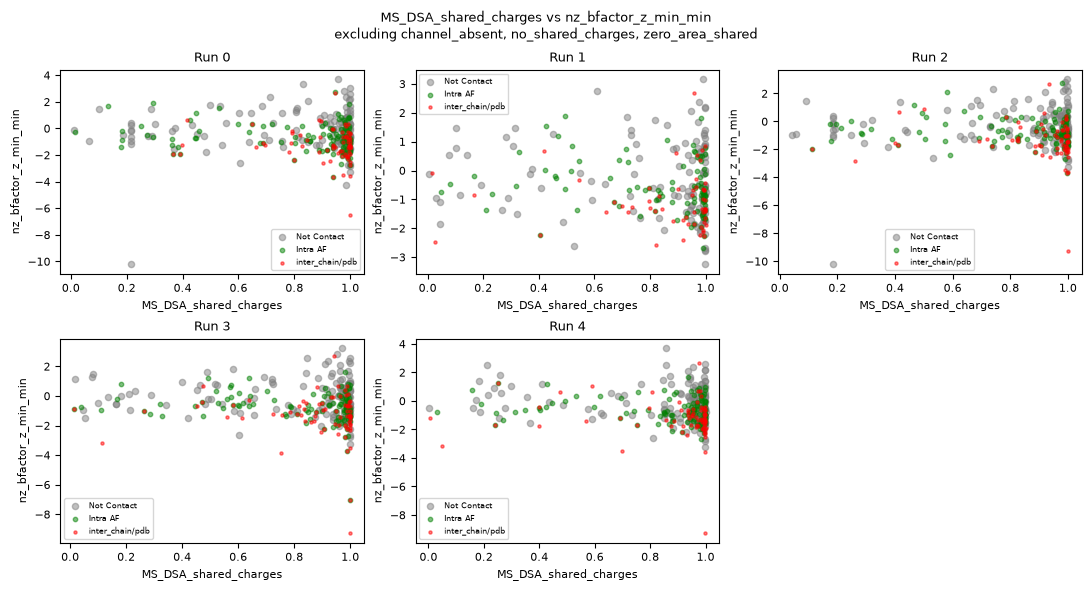

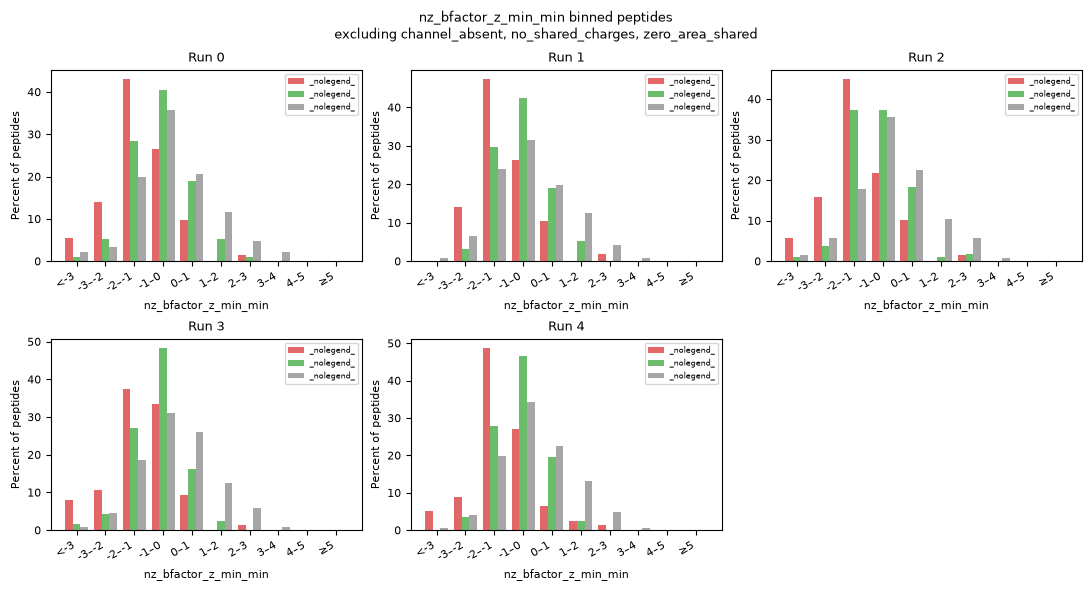

residue max (avg_bfactor_z_mean_max): Spearman correlation with MS_DSA_shared_charges


spearman                          n                     
group    Inter Intra AF Not Contact Inter Intra AF Not Contact
run                                                           
0       -0.038   -0.118      -0.079  72.0    117.0       153.0
1       -0.130   -0.241       0.015  57.0     94.0       126.0
2        0.118    0.013       0.031  69.0    111.0       131.0
3       -0.046   -0.055      -0.006  75.0    118.0       141.0
4       -0.115   -0.134      -0.061  78.0    120.0       152.0

Inter PDB: 72 rows  (0.278 with MS_DSA_shared_charges < 0.9)
Intra PDB: 185 rows  (0.351 with MS_DSA_shared_charges < 0.9)
Intra AF: 203 rows  (0.404 with MS_DSA_shared_charges < 0.9)
Not contact: 432 rows  (0.426 with MS_DSA_shared_charges < 0.9)
Inter PDB: 57 rows  (0.351 with MS_DSA_shared_charges < 0.9)
Intra PDB: 170 rows  (0.388 with MS_DSA_shared_charges < 0.9)
Intra AF: 179 rows  (0.447 with MS_DSA_shared_charges < 0.9)
Not contact: 380 rows  (0.445 with MS_DSA_shared_charges < 0.9)


Inter PDB: 69 rows  (0.275 with MS_DSA_shared_charges < 0.9)
Intra PDB: 189 rows  (0.365 with MS_DSA_shared_charges < 0.9)
Intra AF: 178 rows  (0.433 with MS_DSA_shared_charges < 0.9)
Not contact: 387 rows  (0.390 with MS_DSA_shared_charges < 0.9)
Inter PDB: 75 rows  (0.387 with MS_DSA_shared_charges < 0.9)
Intra PDB: 203 rows  (0.379 with MS_DSA_shared_charges < 0.9)
Intra AF: 202 rows  (0.411 with MS_DSA_shared_charges < 0.9)
Not contact: 406 rows  (0.441 with MS_DSA_shared_charges < 0.9)
Inter PDB: 78 rows  (0.218 with MS_DSA_shared_charges < 0.9)
Intra PDB: 216 rows  (0.356 with MS_DSA_shared_charges < 0.9)
Intra AF: 209 rows  (0.388 with MS_DSA_shared_charges < 0.9)
Not contact: 443 rows  (0.406 with MS_DSA_shared_charges < 0.9)


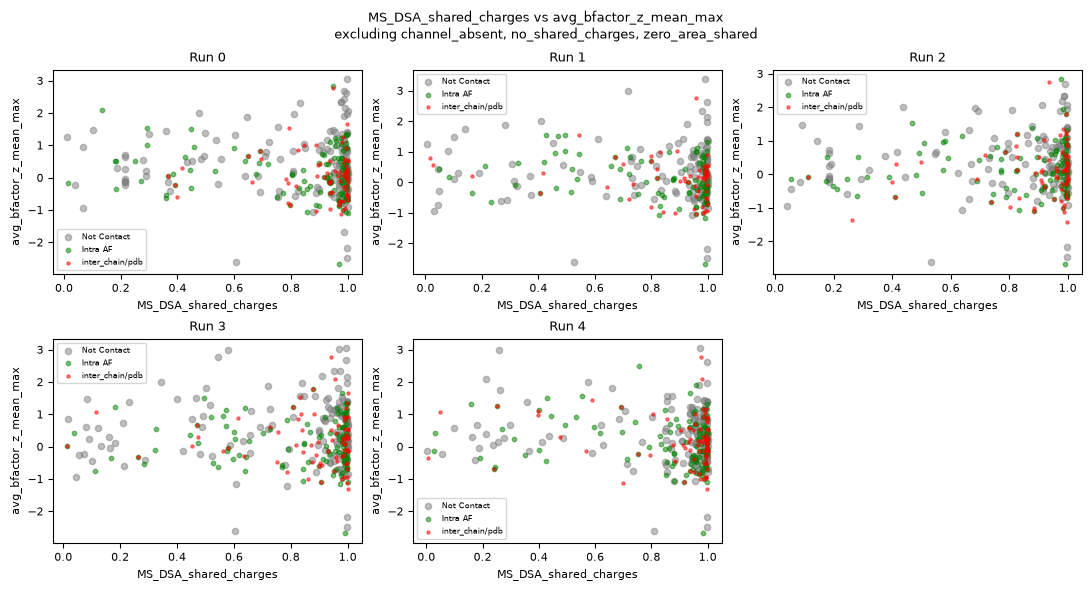

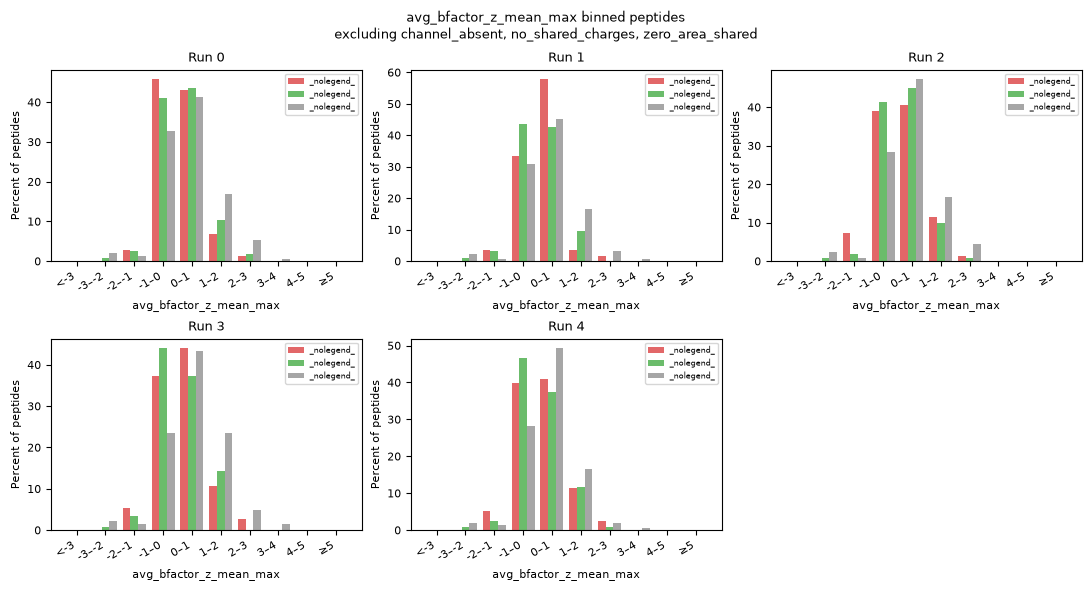

residue min (avg_bfactor_z_mean_min): Spearman correlation with MS_DSA_shared_charges


spearman                          n                     
group    Inter Intra AF Not Contact Inter Intra AF Not Contact
run                                                           
0        0.006   -0.109      -0.099  72.0    117.0       153.0
1       -0.072   -0.236      -0.008  57.0     94.0       126.0
2        0.094   -0.012       0.032  69.0    111.0       131.0
3       -0.018   -0.078      -0.007  75.0    118.0       141.0
4       -0.018   -0.092      -0.059  78.0    120.0       152.0

Inter PDB: 72 rows  (0.278 with MS_DSA_shared_charges < 0.9)
Intra PDB: 185 rows  (0.351 with MS_DSA_shared_charges < 0.9)
Intra AF: 203 rows  (0.404 with MS_DSA_shared_charges < 0.9)
Not contact: 432 rows  (0.426 with MS_DSA_shared_charges < 0.9)
Inter PDB: 57 rows  (0.351 with MS_DSA_shared_charges < 0.9)
Intra PDB: 170 rows  (0.388 with MS_DSA_shared_charges < 0.9)
Intra AF: 179 rows  (0.447 with MS_DSA_shared_charges < 0.9)
Not contact: 380 rows  (0.445 with MS_DSA_shared_charges < 0.9)
Inter PDB: 69 rows  (0.275 with MS_DSA_shared_charges < 0.9)
Intra PDB: 189 rows  (0.365 with MS_DSA_shared_charges < 0.9)
Intra AF: 178 rows  (0.433 with MS_DSA_shared_charges < 0.9)
Not contact: 387 rows  (0.390 with MS_DSA_shared_charges < 0.9)
Inter PDB: 75 rows  (0.387 with MS_DSA_shared_charges < 0.9)
Intra PDB: 203 rows  (0.379 with MS_DSA_shared_charges < 0.9)
Intra AF: 202 rows  (0.411 with MS_DSA_shared_charges < 0.9)
Not contact: 406 rows  (0.441 with MS_DSA_shared_charges < 0.9)


Inter PDB: 78 rows  (0.218 with MS_DSA_shared_charges < 0.9)
Intra PDB: 216 rows  (0.356 with MS_DSA_shared_charges < 0.9)
Intra AF: 209 rows  (0.388 with MS_DSA_shared_charges < 0.9)
Not contact: 443 rows  (0.406 with MS_DSA_shared_charges < 0.9)


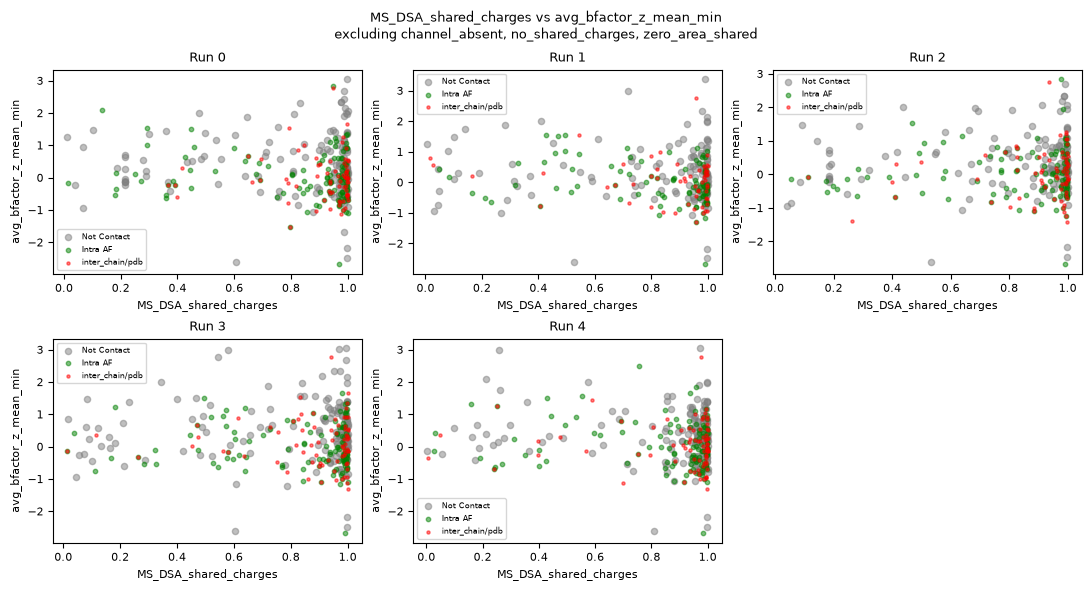

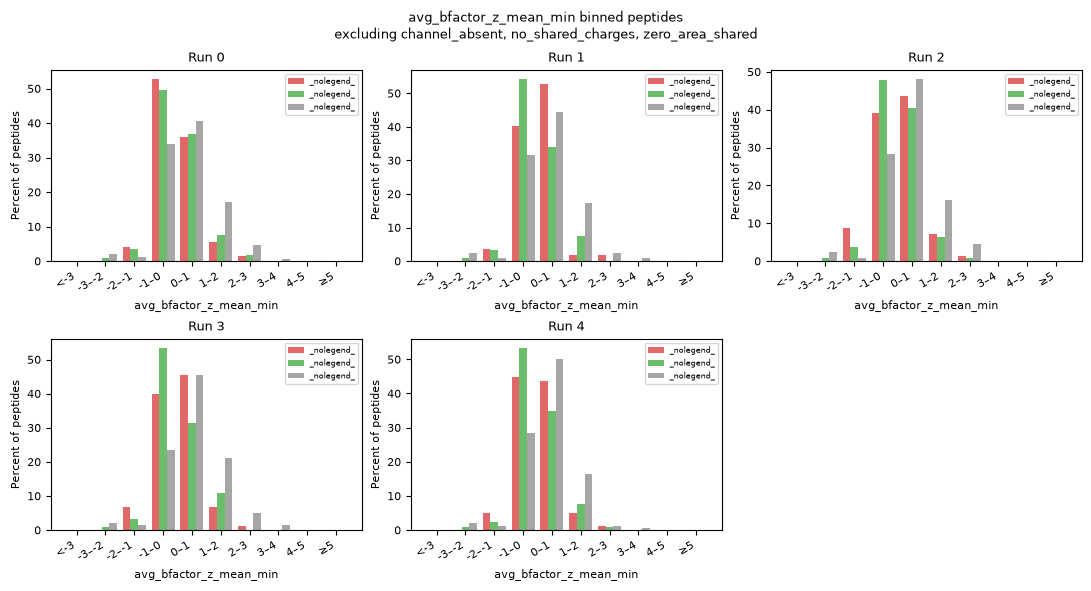

In [5]:
common = dict(bond_type=bond_type, strict=strict, exclude=versions["B. zero areas excluded"])
for name, column in bfactor_columns.items():
    print(f"{name} ({column}): Spearman correlation with {dsa_column}")
    display(correlation_table(ms_dsa_by_run, dsa_column, column, **common))
    plot_runs(ms_dsa_by_run, plot_dsa_vs_sasa_with_binding_annotation, sasa_column=column, dsa_column=dsa_column, **common)
    plt.show()
    plot_runs(ms_dsa_by_run, binned_histogram, column=column, bins=bfactor_bins, require=dsa_column, **common)
    plt.show()